In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import copy
import math
train = pd.read_csv("train.csv")
train.head()




,date,high,low,momentum_index,beta_indicator,risk_premium,index,volatility_factor,technical_score,oscillator_value,liquidity_ratio,open,quant_index,trend_strength,market_sentiment,close,volume,alpha_signal,symbols
0,2012-06-22,24.797176,162.793195,153.349972,90.290064,277.383362,62235.0,105.868473,128.280484,38.359969,154.844720,122.656593,3817.034814,-48.017571,-42.552169,95.610001,NaN,126.405476,MRO
1,2013-02-27,84.148858,62.911473,123.066280,99.689780,116.635811,48784.0,116.700703,8.730951,-35.866296,-53.482145,48.429243,4522.962303,149.657066,221.824044,27.410000,24383100.0,-22.111984,HRS
2,2010-07-19,162.714072,7.813419,50.140068,-30.373609,145.254746,233118.0,302.752221,-40.118103,-50.358825,27.921367,144.410310,1277.720791,284.891018,58.834733,25.230000,38181800.0,20.068656,Low
3,2015-12-31,-128.017977,-38.679447,-21.881272,-173.386894,-123.314003,28867.0,-3.662459,81.801806,-53.396998,-11.014860,-12.281054,636.545321,-210.812924,137.518347,30.000000,944600.0,75.297134,ULTA
4,2012-11-12,204.768157,-6.981525,-38.978256,64.867265,-90.095079,182732.0,-157.223822,-76.111066,149.650023,-29.829836,-48.492927,3044.960784,293.534187,15.030557,68.480003,2780300.0,82.056444,Low


In [2]:
train.head(2)


,date,high,low,momentum_index,beta_indicator,risk_premium,index,volatility_factor,technical_score,oscillator_value,liquidity_ratio,open,quant_index,trend_strength,market_sentiment,close,volume,alpha_signal,symbols
0,2012-06-22,24.797176,162.793195,153.349972,90.290064,277.383362,62235.0,105.868473,128.280484,38.359969,154.844720,122.656593,3817.034814,-48.017571,-42.552169,95.610001,NaN,126.405476,MRO
1,2013-02-27,84.148858,62.911473,123.066280,99.689780,116.635811,48784.0,116.700703,8.730951,-35.866296,-53.482145,48.429243,4522.962303,149.657066,221.824044,27.410000,24383100.0,-22.111984,HRS


In [3]:
print("\n Duplicated rows: ",train.duplicated().sum())


 Duplicated rows:  20969


In [4]:
train = train.drop_duplicates()

In [5]:
print("\n Duplicated rows: ",train.duplicated().sum())



 Duplicated rows:  0


In [6]:
x_train = train[['high', 'low', 'momentum_index', 'beta_indicator', 'risk_premium', 'index',
                    'volatility_factor', 'technical_score', 'oscillator_value', 'liquidity_ratio',
                    'open', 'quant_index', 'trend_strength', 'market_sentiment', 'volume', 'alpha_signal']].to_numpy()

In [7]:
y_train = train[["close"]].to_numpy()

In [8]:
x_train = np.nan_to_num(x_train, nan=0.0)
y_train = np.nan_to_num(y_train, nan=0.0)

In [9]:
def prediction_model(x ,w ,b):
    w = w.reshape(-1)
    p  = np.dot(x, w) + b
    return p

In [25]:
def compute_cost(X, y, w, b): 
    
    m = X.shape[0]
    cost = 0.0

    y = y.flatten()
    
    for i in range(m):                                
        f_wb_i = np.dot(X[i],w) + b           
        cost = cost + (f_wb_i - y[i])**2       
    cost = cost / (2 * m)                         
    return float(cost)



    

In [26]:

def compute_gradient(X, y, w, b): 
    m,n = X.shape           
    dj_dw = np.zeros((n,))
    dj_db = 0.0

    y=y.flatten()

    for i in range(m):                             
        err = float(np.dot(X[i], w) + b - y[i])
  
        for j in range(n):                         
            dj_dw[j] = dj_dw[j] + err * X[i, j]    
        dj_db = dj_db + err                        
    dj_dw = dj_dw / m                                
    dj_db = dj_db / m                                
        
    return dj_db, dj_dw


In [27]:
def gradient_descent(X, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters): 
    J_history = []
    w = copy.deepcopy(w_in) 
    b = b_in
    
    for i in range(num_iters):

      
        dj_db, dj_dw = gradient_function(X, y, w, b)   

       
        w = w - alpha * dj_dw               
        b = b - alpha * dj_db              
      
        
        if i < 100000:      
            J_history.append(cost_function(X, y, w, b))

            
            if i % math.ceil(num_iters / 10) == 0:
                print(f"Iteration {i:4d}: Cost {float(J_history[-1]):8.2f}")

    return w, b, J_history

    

In [28]:
def zscore_normalize_features(X):
    mu     = np.mean(X, axis=0)                
    sigma  = np.std(X, axis=0)                  
    X_norm = (X - mu) / sigma      

    return (X_norm, mu, sigma)

In [29]:
def zscore_normalize_Targets(Y):
    
 y_mu = np.mean(Y)
 y_sigma = np.std(Y)
 y_norm = (Y - y_mu)/y_sigma

 return(y_mu,y_sigma,y_norm)

In [37]:

w_initial = np.zeros(16)
b_initial = 0
Iterations = 250

a = 0.001
x_train_norm, x_train_mu,sigma_norm = zscore_normalize_features(x_train)
y_train_norm, y_train_mu, y_sigma_mu = zscore_normalize_features(y_train)


In [38]:
w_final,b_final,J_hist = gradient_descent(x_train_norm,y_train_norm,w_initial,b_initial,compute_cost,compute_gradient,a,Iterations)
f = np.dot(x_train_norm,w_final) + b_final
f = np.ravel(f)

y_train_norm = np.ravel(y_train_norm)

rmse_value = np.sqrt(np.mean((f-y_train_norm)**2))
print(f"Rmse = {rmse_value:6f}")
import numpy as np

ss_res = np.sum((y_train_norm - f) ** 2)         
ss_tot = np.sum((y_train_norm - np.mean(y_train_norm)) ** 2) 
r2 = 1 - (ss_res / ss_tot)

print(f"R² Score: {r2:.6f}")

Iteration    0: Cost     0.50
Iteration   25: Cost     0.40
Iteration   50: Cost     0.32
Iteration   75: Cost     0.27
Iteration  100: Cost     0.22
Iteration  125: Cost     0.19
Iteration  150: Cost     0.16
Iteration  175: Cost     0.14
Iteration  200: Cost     0.12
Iteration  225: Cost     0.11
Rmse = 0.450153
R² Score: 0.797362


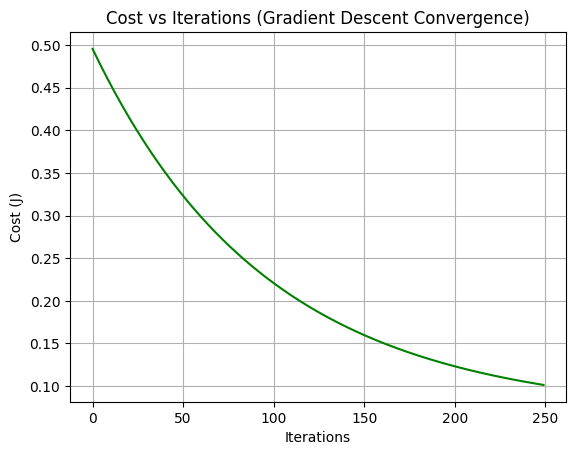

In [39]:
plt.close('all')
plt.plot(range(Iterations), J_hist, color='green')
plt.xlabel("Iterations")
plt.ylabel("Cost (J)")
plt.title("Cost vs Iterations (Gradient Descent Convergence)")
plt.grid(True)
plt.show()


In [45]:
w_initial = np.zeros(16)
b_initial = 0
Iterations = 100
a = 0.008
x_train_norm, x_train_mu,sigma_norm = zscore_normalize_features(x_train)
y_train_norm, y_train_mu, y_sigma_mu = zscore_normalize_features(y_train)

In [46]:
w_final,b_final,J_hist = gradient_descent(x_train_norm,y_train_norm,w_initial,b_initial,compute_cost,compute_gradient,a,Iterations)
f = np.dot(x_train_norm,w_final) + b_final
f = np.ravel(f)

y_train_norm = np.ravel(y_train_norm)

rmse_value = np.sqrt(np.mean((f-y_train_norm)**2))
print(f"Rmse = {rmse_value:6f}")
import numpy as np

ss_res = np.sum((y_train_norm - f) ** 2)         
ss_tot = np.sum((y_train_norm - np.mean(y_train_norm)) ** 2) 
r2 = 1 - (ss_res / ss_tot)

print(f"R² Score: {r2:.6f}")

Iteration    0: Cost     0.47
Iteration   10: Cost     0.24
Iteration   20: Cost     0.14
Iteration   30: Cost     0.10
Iteration   40: Cost     0.08
Iteration   50: Cost     0.07
Iteration   60: Cost     0.07
Iteration   70: Cost     0.06
Iteration   80: Cost     0.06
Iteration   90: Cost     0.06
Rmse = 0.343610
R² Score: 0.881932


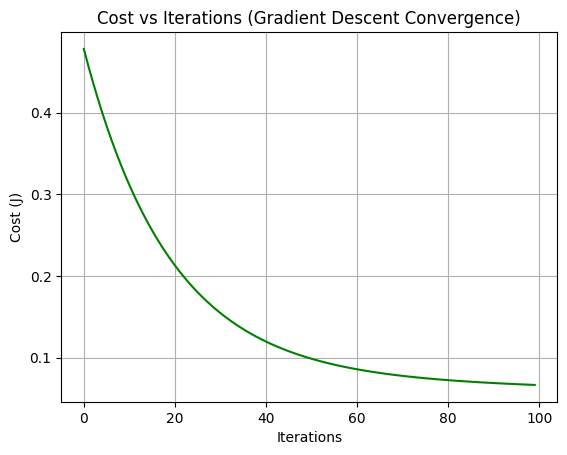

In [44]:
plt.close('all')
plt.plot(range(Iterations), J_hist, color='green')
plt.xlabel("Iterations")
plt.ylabel("Cost (J)")
plt.title("Cost vs Iterations (Gradient Descent Convergence)")
plt.grid(True)
plt.show()

In [52]:
w_initial = np.zeros(16)
b_initial = 0
Iterations = 500
a = 0.02
x_train_norm, x_train_mu,sigma_norm = zscore_normalize_features(x_train)
y_train_norm, y_train_mu, y_sigma_mu = zscore_normalize_features(y_train)

In [53]:
w_final,b_final,J_hist = gradient_descent(x_train_norm,y_train_norm,w_initial,b_initial,compute_cost,compute_gradient,a,Iterations)
f = np.dot(x_train_norm,w_final) + b_final
f = np.ravel(f)

y_train_norm = np.ravel(y_train_norm)

rmse_value = np.sqrt(np.mean((f-y_train_norm)**2))
print(f"Rmse = {rmse_value:6f}")
import numpy as np

ss_res = np.sum((y_train_norm - f) ** 2)         
ss_tot = np.sum((y_train_norm - np.mean(y_train_norm)) ** 2) 
r2 = 1 - (ss_res / ss_tot)

print(f"R² Score: {r2:.6f}")


Iteration    0: Cost     0.42
Iteration   50: Cost     0.06
Iteration  100: Cost     0.05
Iteration  150: Cost     0.04
Iteration  200: Cost     0.03
Iteration  250: Cost     0.03
Iteration  300: Cost     0.03
Iteration  350: Cost     0.02
Iteration  400: Cost     0.02
Iteration  450: Cost     0.02
Rmse = 0.200870
R² Score: 0.959651


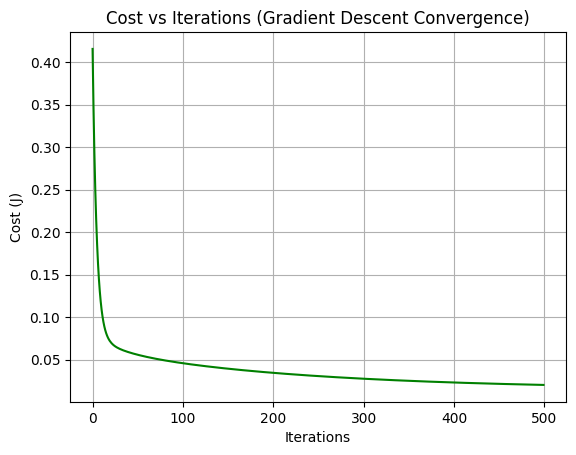

In [54]:
plt.close('all')
plt.plot(range(Iterations), J_hist, color='green')
plt.xlabel("Iterations")
plt.ylabel("Cost (J)")
plt.title("Cost vs Iterations (Gradient Descent Convergence)")
plt.grid(True)
plt.show()